In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzAz'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

print("✅ Environnement prêt")

✅ Environnement prêt


In [3]:
#| label: dataset-ml
np.random.seed(42)
n = 500

immo = pd.DataFrame({
    "surface": np.random.normal(75, 25, n).clip(20, 200).round(1),
    "nb_pieces": np.random.randint(1, 7, n),
    "etage": np.random.randint(0, 8, n),
    "quartier": np.random.choice(
        ["Centre", "Nord", "Sud", "Est", "Ouest"],
        n, p=[0.35, 0.2, 0.2, 0.15, 0.1]
    ),
    "etat": np.random.choice(
        ["Mauvais", "Correct", "Bon", "Excellent"],
        n, p=[0.1, 0.3, 0.4, 0.2]
    ),
    "type_bien": np.random.choice(["Appartement", "Maison"], n, p=[0.7, 0.3]),
    "date_mise_en_vente": pd.to_datetime(
        np.random.choice(pd.date_range("2023-01-01", "2024-12-31"), n)
    ),
})

# Prix : relation plausible avec les features
immo["prix"] = (
    2500 * immo["surface"]
    + 15000 * immo["nb_pieces"]
    + 3000 * immo["etage"]
    + immo["quartier"].map({"Centre": 60000, "Nord": 15000, "Sud": 25000, "Est": 10000, "Ouest": 5000})
    + immo["etat"].map({"Mauvais": -30000, "Correct": 0, "Bon": 20000, "Excellent": 40000})
    + np.where(immo["type_bien"] == "Maison", 50000, 0)
    + np.random.normal(0, 15000, n)
).round().astype(int)

print(f"✅ Dataset immobilier : {immo.shape}")
immo.head()

✅ Dataset immobilier : (500, 8)


,surface,nb_pieces,etage,quartier,etat,type_bien,date_mise_en_vente,prix
0,87.4,2,7,Nord,Bon,Maison,2024-03-09,386830
1,71.5,2,1,Nord,Correct,Appartement,2023-11-27,212087
2,91.2,3,0,Centre,Bon,Appartement,2023-05-23,331332
3,113.1,3,6,Centre,Bon,Maison,2024-06-23,497205
4,69.1,5,2,Centre,Correct,Appartement,2023-10-05,315881


In [4]:
# Exemple simple
target = pd.Series(["chat", "chien", "chat", "oiseau", "chien", "chat"])

le = LabelEncoder()
target_encoded = le.fit_transform(target)

print(f"Original : {target.tolist()}")
print(f"Encodé   : {target_encoded.tolist()}")
print(f"Classes  : {le.classes_}")

Original : ['chat', 'chien', 'chat', 'oiseau', 'chien', 'chat']
Encodé   : [0, 1, 0, 2, 1, 0]
Classes  : ['chat' 'chien' 'oiseau']


In [5]:
# Inverse : retrouver les labels
inverse = le.inverse_transform(target_encoded)
print(f"Inverse  : {inverse.tolist()}")

Inverse  : ['chat', 'chien', 'chat', 'oiseau', 'chien', 'chat']


In [6]:
# Exemple sur quartier
quartiers = pd.DataFrame({"quartier": ["Centre", "Nord", "Centre", "Sud", "Nord"]})

# Méthode 1 : pandas.get_dummies (simple)
oh_pandas = pd.get_dummies(quartiers, columns=["quartier"])
print("Avec pandas.get_dummies :")
print(oh_pandas)

Avec pandas.get_dummies :
   quartier_Centre  quartier_Nord  quartier_Sud
0             True          False         False
1            False           True         False
2             True          False         False
3            False          False          True
4            False           True         False


In [7]:
# Méthode 2 : sklearn.OneHotEncoder (plus puissant pour les pipelines)
ohe = OneHotEncoder(sparse_output=False)
oh_sklearn = ohe.fit_transform(quartiers[["quartier"]])

print(f"\nAvec OneHotEncoder :")
print(pd.DataFrame(oh_sklearn, columns=ohe.get_feature_names_out()))


Avec OneHotEncoder :
   quartier_Centre  quartier_Nord  quartier_Sud
0              1.0            0.0           0.0
1              0.0            1.0           0.0
2              1.0            0.0           0.0
3              0.0            0.0           1.0
4              0.0            1.0           0.0


In [8]:
# Exemple sur etat : Mauvais < Correct < Bon < Excellent
etats = pd.DataFrame({"etat": ["Bon", "Excellent", "Mauvais", "Correct", "Bon"]})

# Il faut FOURNIR l'ordre explicitement
ordre_etat = ["Mauvais", "Correct", "Bon", "Excellent"]
oe = OrdinalEncoder(categories=[ordre_etat])
etats_encoded = oe.fit_transform(etats[["etat"]])

print(pd.DataFrame({
    "etat_original": etats["etat"],
    "etat_encoded": etats_encoded.flatten().astype(int)
}))

  etat_original  etat_encoded
0           Bon             2
1     Excellent             3
2       Mauvais             0
3       Correct             1
4           Bon             2


In [9]:
#| eval: false
# TODO: Exercice 1

In [10]:
df = immo.copy()

# 1 & 2. One-Hot Encoding
df = pd.get_dummies(df, columns=["quartier", "type_bien"], drop_first=False)

# 3. Ordinal Encoding sur etat
ordre_etat = ["Mauvais", "Correct", "Bon", "Excellent"]
oe = OrdinalEncoder(categories=[ordre_etat])
df["etat"] = oe.fit_transform(df[["etat"]]).astype(int)

# On retire la date (on la traitera dans la section suivante)
df = df.drop(columns=["date_mise_en_vente"])

# 4. Résultat
immo_encoded = df
print(f"Shape : {immo_encoded.shape}")
print(f"Colonnes :\n{immo_encoded.columns.tolist()}")

# 5. Dtypes
print(f"\n{immo_encoded.dtypes}")

Shape : (500, 12)
Colonnes :
['surface', 'nb_pieces', 'etage', 'etat', 'prix', 'quartier_Centre', 'quartier_Est', 'quartier_Nord', 'quartier_Ouest', 'quartier_Sud', 'type_bien_Appartement', 'type_bien_Maison']

surface                  float64
nb_pieces                  int32
etage                      int32
etat                       int64
prix                       int64
quartier_Centre             bool
quartier_Est                bool
quartier_Nord               bool
quartier_Ouest              bool
quartier_Sud                bool
type_bien_Appartement       bool
type_bien_Maison            bool
dtype: object


In [11]:
scaler = StandardScaler()
surface_scaled = scaler.fit_transform(immo[["surface"]])

print(f"Avant : moyenne = {immo['surface'].mean():.1f}, std = {immo['surface'].std():.1f}")
print(f"Après : moyenne = {surface_scaled.mean():.3f}, std = {surface_scaled.std():.3f}")

Avant : moyenne = 75.2, std = 24.3
Après : moyenne = 0.000, std = 1.000


In [12]:
scaler = MinMaxScaler()
surface_minmax = scaler.fit_transform(immo[["surface"]])

print(f"Min : {surface_minmax.min():.3f}")
print(f"Max : {surface_minmax.max():.3f}")

Min : 0.000
Max : 1.000


In [13]:
scaler = RobustScaler()
surface_robust = scaler.fit_transform(immo[["surface"]])

print(f"Médiane après : {np.median(surface_robust):.3f}")
print(f"IQR après     : {np.subtract(*np.percentile(surface_robust, [75, 25])):.3f}")

Médiane après : 0.000
IQR après     : 1.000


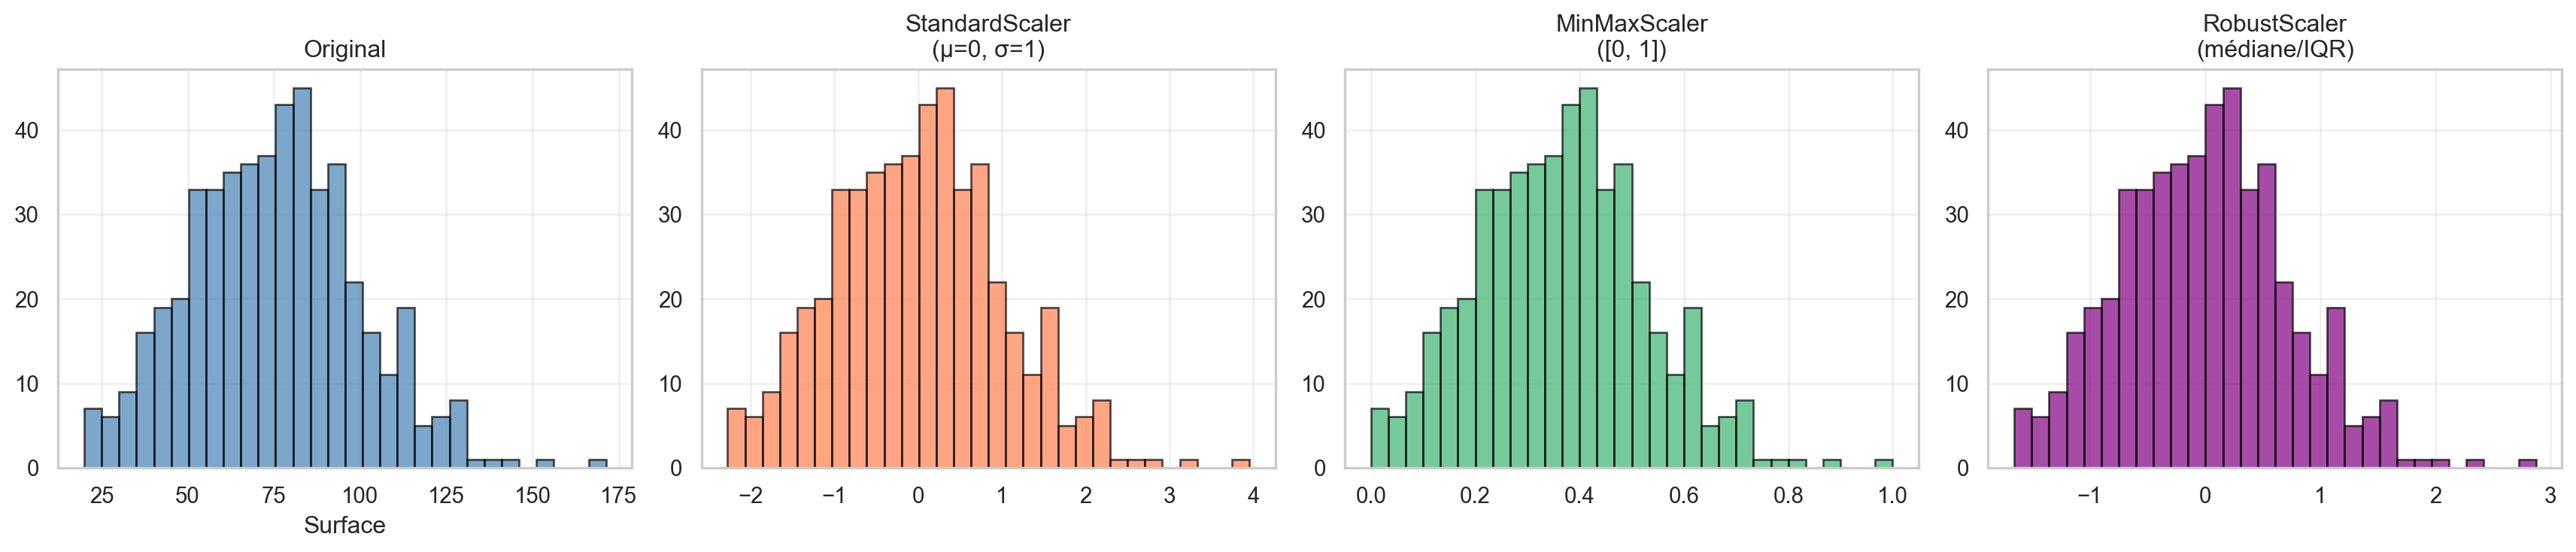

In [14]:
#| label: fig-scalers
#| fig-cap: Comparaison des 3 scalers

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Original
axes[0].hist(immo["surface"], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].set_title("Original")
axes[0].set_xlabel("Surface")

# Standard
ss = StandardScaler()
axes[1].hist(ss.fit_transform(immo[["surface"]]), bins=30, color="coral", edgecolor="black", alpha=0.7)
axes[1].set_title("StandardScaler\n(μ=0, σ=1)")

# MinMax
mm = MinMaxScaler()
axes[2].hist(mm.fit_transform(immo[["surface"]]), bins=30, color="mediumseagreen", edgecolor="black", alpha=0.7)
axes[2].set_title("MinMaxScaler\n([0, 1])")

# Robust
rs = RobustScaler()
axes[3].hist(rs.fit_transform(immo[["surface"]]), bins=30, color="purple", edgecolor="black", alpha=0.7)
axes[3].set_title("RobustScaler\n(médiane/IQR)")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
#| eval: false
# TODO: Exercice 2

In [16]:
# Recréer immo_encoded si besoin
df = immo.copy()
df = pd.get_dummies(df, columns=["quartier", "type_bien"], drop_first=False)
ordre_etat = ["Mauvais", "Correct", "Bon", "Excellent"]
oe = OrdinalEncoder(categories=[ordre_etat])
df["etat"] = oe.fit_transform(df[["etat"]]).astype(int)
df = df.drop(columns=["date_mise_en_vente"])
immo_encoded = df

# 1. X et y
X = immo_encoded.drop(columns=["prix"])
y = immo_encoded["prix"]

# 2 & 3. StandardScaler
ss = StandardScaler()
X_std = pd.DataFrame(ss.fit_transform(X), columns=X.columns)
print("StandardScaler :")
print(f"  Moyennes : {X_std.mean().abs().max():.6f} (max, doit être ≈ 0)")
print(f"  Std      : {X_std.std().values.round(3)}")

StandardScaler :
  Moyennes : 0.000000 (max, doit être ≈ 0)
  Std      : [1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001]


In [17]:
# 4. MinMaxScaler
mm = MinMaxScaler()
X_mm = pd.DataFrame(mm.fit_transform(X), columns=X.columns)
print("MinMaxScaler :")
print(f"  Min : {X_mm.min().min():.6f} (doit être 0)")
print(f"  Max : {X_mm.max().max():.6f} (doit être 1)")

MinMaxScaler :
  Min : 0.000000 (doit être 0)
  Max : 1.000000 (doit être 1)


In [18]:
df = immo.copy()

# Extractions de composantes
df["annee"] = df["date_mise_en_vente"].dt.year
df["mois"] = df["date_mise_en_vente"].dt.month
df["jour_semaine"] = df["date_mise_en_vente"].dt.dayofweek  # 0 = lundi
df["trimestre"] = df["date_mise_en_vente"].dt.quarter
df["est_weekend"] = df["date_mise_en_vente"].dt.dayofweek.isin([5, 6]).astype(int)
df["jour_annee"] = df["date_mise_en_vente"].dt.dayofyear

print(df[["date_mise_en_vente", "annee", "mois", "jour_semaine", "trimestre", "est_weekend"]].head())

  date_mise_en_vente  annee  mois  jour_semaine  trimestre  est_weekend
0         2024-03-09   2024     3             5          1            1
1         2023-11-27   2023    11             0          4            0
2         2023-05-23   2023     5             1          2            0
3         2024-06-23   2024     6             6          2            1
4         2023-10-05   2023    10             3          4            0


In [19]:
# Nombre de jours depuis la mise en vente
reference = pd.Timestamp("2025-01-01")
df["jours_depuis_vente"] = (reference - df["date_mise_en_vente"]).dt.days

print(df[["date_mise_en_vente", "jours_depuis_vente"]].head())

  date_mise_en_vente  jours_depuis_vente
0         2024-03-09                 298
1         2023-11-27                 401
2         2023-05-23                 589
3         2024-06-23                 192
4         2023-10-05                 454


In [20]:
# Encodage cyclique du mois
df["mois_sin"] = np.sin(2 * np.pi * df["mois"] / 12)
df["mois_cos"] = np.cos(2 * np.pi * df["mois"] / 12)

# Vérification : décembre (12) et janvier (1) sont maintenant proches
print(f"Janvier  : sin={np.sin(2*np.pi*1/12):.3f}, cos={np.cos(2*np.pi*1/12):.3f}")
print(f"Décembre : sin={np.sin(2*np.pi*12/12):.3f}, cos={np.cos(2*np.pi*12/12):.3f}")
print(f"Juin     : sin={np.sin(2*np.pi*6/12):.3f}, cos={np.cos(2*np.pi*6/12):.3f}")

Janvier  : sin=0.500, cos=0.866
Décembre : sin=-0.000, cos=1.000
Juin     : sin=0.000, cos=-1.000


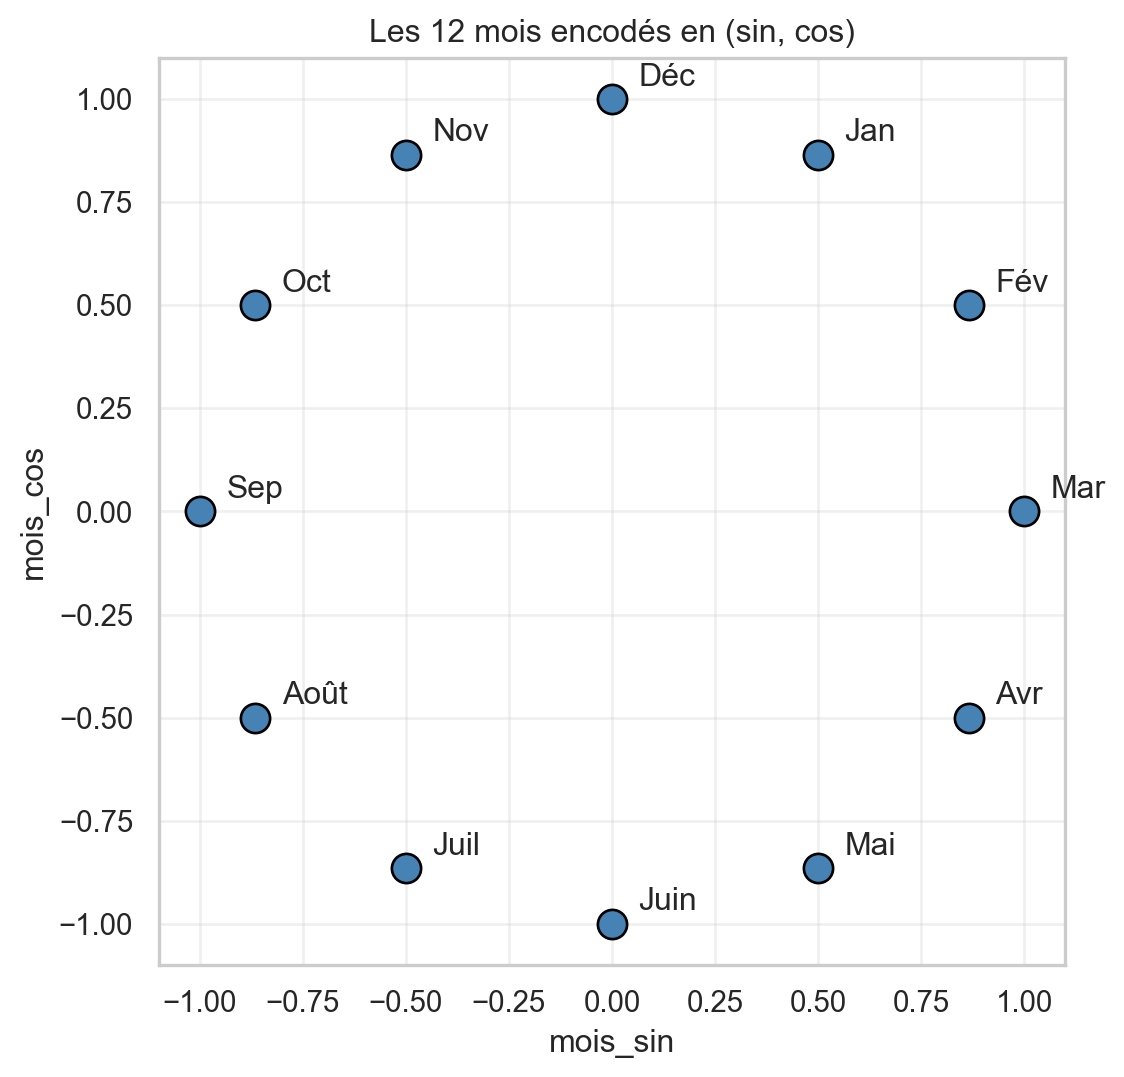

In [21]:
#| label: fig-cyclique
#| fig-cap: L'encodage cyclique place les 12 mois sur un cercle

fig, ax = plt.subplots(figsize=(6, 6))

# Tracer les 12 mois sur un cercle
mois_list = range(1, 13)
noms_mois = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]

for m, nom in zip(mois_list, noms_mois):
    s = np.sin(2 * np.pi * m / 12)
    c = np.cos(2 * np.pi * m / 12)
    ax.scatter(s, c, s=120, color="steelblue", edgecolor="black")
    ax.annotate(nom, (s, c), xytext=(10, 5), textcoords="offset points")

ax.set_xlabel("mois_sin")
ax.set_ylabel("mois_cos")
ax.set_title("Les 12 mois encodés en (sin, cos)")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [22]:
#| eval: false
# TODO: Exercice 3

In [23]:
df = immo.copy()

# 1. Features de base
df["mois"] = df["date_mise_en_vente"].dt.month
df["jour_semaine"] = df["date_mise_en_vente"].dt.dayofweek
df["est_weekend"] = df["jour_semaine"].isin([5, 6]).astype(int)

# 2. Encodage cyclique du jour de la semaine
df["jour_semaine_sin"] = np.sin(2 * np.pi * df["jour_semaine"] / 7)
df["jour_semaine_cos"] = np.cos(2 * np.pi * df["jour_semaine"] / 7)

# 3. Vérification : distance entre lundi (0) et dimanche (6)
lundi = np.array([np.sin(0), np.cos(0)])
dimanche = np.array([np.sin(2*np.pi*6/7), np.cos(2*np.pi*6/7)])
mercredi = np.array([np.sin(2*np.pi*3/7), np.cos(2*np.pi*3/7)])

dist_lun_dim = np.linalg.norm(lundi - dimanche)
dist_lun_mer = np.linalg.norm(lundi - mercredi)

print(f"Distance lundi ↔ dimanche  : {dist_lun_dim:.3f}")
print(f"Distance lundi ↔ mercredi  : {dist_lun_mer:.3f}")
print(f"\nLundi et dimanche sont plus proches que lundi et mercredi : {dist_lun_dim < dist_lun_mer}")

Distance lundi ↔ dimanche  : 0.868
Distance lundi ↔ mercredi  : 1.950

Lundi et dimanche sont plus proches que lundi et mercredi : True


In [24]:
# Le split classique : 80% train / 20% test
X = immo_encoded.drop(columns=["prix"])
y = immo_encoded["prix"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% pour le test
    random_state=42      # reproductibilité
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (400, 11)
X_test  : (100, 11)
y_train : (400,)
y_test  : (100,)


In [25]:
# Création d'un problème de classification déséquilibré
y_binaire = (immo_encoded["prix"] > immo_encoded["prix"].median()).astype(int)

# Split sans stratification
X_tr, X_te, y_tr, y_te = train_test_split(X, y_binaire, test_size=0.2, random_state=42)
print("Sans stratification :")
print(f"  y_train : {y_tr.mean():.3f} de classe 1")
print(f"  y_test  : {y_te.mean():.3f} de classe 1")

# Split avec stratification
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_binaire, test_size=0.2, random_state=42, stratify=y_binaire
)
print("\nAvec stratification :")
print(f"  y_train : {y_tr.mean():.3f} de classe 1")
print(f"  y_test  : {y_te.mean():.3f} de classe 1")

Sans stratification :
  y_train : 0.505 de classe 1
  y_test  : 0.480 de classe 1

Avec stratification :
  y_train : 0.500 de classe 1
  y_test  : 0.500 de classe 1


In [26]:
# Exemple complet
X = immo_encoded.drop(columns=["prix"])
y = immo_encoded["prix"]

# 1. Split d'abord
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Scaler : fit sur train, transform sur train ET test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    # ← transform seulement, pas fit_transform

# Vérification : les moyennes de X_test ne sont pas exactement 0
# (c'est normal : on utilise les stats de X_train)
print(f"X_train_scaled : moyenne = {X_train_scaled.mean():.4f}")
print(f"X_test_scaled  : moyenne = {X_test_scaled.mean():.4f}  (≠ 0 est normal)")

X_train_scaled : moyenne = -0.0000
X_test_scaled  : moyenne = -0.0113  (≠ 0 est normal)


In [27]:
from sklearn.pipeline import Pipeline

# Pipeline = liste d'étapes (nom, transformateur)
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

# Le pipeline se comporte comme un seul objet
X_train_transformed = pipe.fit_transform(X_train)
X_test_transformed = pipe.transform(X_test)

print(f"Résultat : {X_train_transformed.shape}")

Résultat : (400, 11)


In [28]:
# Repartons du DataFrame non-encodé
df_raw = immo.drop(columns=["date_mise_en_vente"])

# Identifier les colonnes par type
cols_num = ["surface", "nb_pieces", "etage"]
cols_cat_nominales = ["quartier", "type_bien"]
cols_cat_ordinales = ["etat"]

# Construire le ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num",     StandardScaler(),                                     cols_num),
        ("cat_nom", OneHotEncoder(sparse_output=False, handle_unknown="ignore"),  cols_cat_nominales),
        ("cat_ord", OrdinalEncoder(categories=[["Mauvais","Correct","Bon","Excellent"]]), cols_cat_ordinales),
    ],
    remainder="drop"  # ignorer les colonnes non listées
)

# Split et application
X_raw = df_raw.drop(columns=["prix"])
y_raw = df_raw["prix"]

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train original  : {X_train.shape}")
print(f"X_train processed : {X_train_processed.shape}")
print(f"\nNoms des features après transformation :")
print(preprocessor.get_feature_names_out())

X_train original  : (400, 6)
X_train processed : (400, 11)

Noms des features après transformation :
['num__surface' 'num__nb_pieces' 'num__etage' 'cat_nom__quartier_Centre'
 'cat_nom__quartier_Est' 'cat_nom__quartier_Nord'
 'cat_nom__quartier_Ouest' 'cat_nom__quartier_Sud'
 'cat_nom__type_bien_Appartement' 'cat_nom__type_bien_Maison'
 'cat_ord__etat']


In [29]:
from sklearn.linear_model import LinearRegression

# Pipeline : préprocessing + modèle en un objet
pipe_complet = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Une seule commande pour tout faire
pipe_complet.fit(X_train, y_train)

# Prédictions
y_pred = pipe_complet.predict(X_test)

# Score (R²)
r2 = pipe_complet.score(X_test, y_test)
print(f"R² sur test : {r2:.3f}")

R² sur test : 0.945


In [30]:
#| eval: false
# TODO: Exercice 4

In [31]:
df = immo.copy()

# 1. Features de dates
df["mois"] = df["date_mise_en_vente"].dt.month
df["jour_semaine"] = df["date_mise_en_vente"].dt.dayofweek
df["est_weekend"] = df["jour_semaine"].isin([5, 6]).astype(int)
df = df.drop(columns=["date_mise_en_vente"])

# 2. Identifier les colonnes
cols_num = ["surface", "nb_pieces", "etage", "mois", "jour_semaine"]
cols_nom = ["quartier", "type_bien"]
cols_ord = ["etat"]
col_binaire = ["est_weekend"]  # déjà 0/1, pas besoin d'encoder

# 3. ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num",     StandardScaler(),           cols_num),
        ("cat_nom", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cols_nom),
        ("cat_ord", OrdinalEncoder(categories=[["Mauvais","Correct","Bon","Excellent"]]), cols_ord),
        ("bin",     "passthrough",              col_binaire),  # laisser tel quel
    ],
    remainder="drop"
)

# 4. Split
X = df.drop(columns=["prix"])
y = df["prix"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Fit sur train, transform
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

# 6. Résultats
print(f"X_train original  : {X_train.shape}")
print(f"X_train processed : {X_train_t.shape}")
print(f"\nFeatures créées :")
for f in preprocessor.get_feature_names_out():
    print(f"  - {f}")

X_train original  : (400, 9)
X_train processed : (400, 14)

Features créées :
  - num__surface
  - num__nb_pieces
  - num__etage
  - num__mois
  - num__jour_semaine
  - cat_nom__quartier_Centre
  - cat_nom__quartier_Est
  - cat_nom__quartier_Nord
  - cat_nom__quartier_Ouest
  - cat_nom__quartier_Sud
  - cat_nom__type_bien_Appartement
  - cat_nom__type_bien_Maison
  - cat_ord__etat
  - bin__est_weekend


In [32]:
#| eval: false
# Recréer immo (le DataFrame de la notion)
np.random.seed(42)
n = 500

immo = pd.DataFrame({
    "surface": np.random.normal(75, 25, n).clip(20, 200).round(1),
    "nb_pieces": np.random.randint(1, 7, n),
    "etage": np.random.randint(0, 8, n),
    "quartier": np.random.choice(
        ["Centre", "Nord", "Sud", "Est", "Ouest"],
        n, p=[0.35, 0.2, 0.2, 0.15, 0.1]
    ),
    "etat": np.random.choice(
        ["Mauvais", "Correct", "Bon", "Excellent"],
        n, p=[0.1, 0.3, 0.4, 0.2]
    ),
    "type_bien": np.random.choice(["Appartement", "Maison"], n, p=[0.7, 0.3]),
    "date_mise_en_vente": pd.to_datetime(
        np.random.choice(pd.date_range("2023-01-01", "2024-12-31"), n)
    ),
})

immo["prix"] = (
    2500 * immo["surface"] + 15000 * immo["nb_pieces"] + 3000 * immo["etage"]
    + immo["quartier"].map({"Centre": 60000, "Nord": 15000, "Sud": 25000, "Est": 10000, "Ouest": 5000})
    + immo["etat"].map({"Mauvais": -30000, "Correct": 0, "Bon": 20000, "Excellent": 40000})
    + np.where(immo["type_bien"] == "Maison", 50000, 0)
    + np.random.normal(0, 15000, n)
).round().astype(int)

In [33]:
#| eval: false
# TODO: Exercice bilan

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Reproduire le dataset (si besoin)
np.random.seed(42)
n = 500
immo_bilan = pd.DataFrame({
    "surface": np.random.normal(75, 25, n).clip(20, 200).round(1),
    "nb_pieces": np.random.randint(1, 7, n),
    "etage": np.random.randint(0, 8, n),
    "quartier": np.random.choice(["Centre", "Nord", "Sud", "Est", "Ouest"], n, 
                                  p=[0.35, 0.2, 0.2, 0.15, 0.1]),
    "etat": np.random.choice(["Mauvais", "Correct", "Bon", "Excellent"], n,
                              p=[0.1, 0.3, 0.4, 0.2]),
    "type_bien": np.random.choice(["Appartement", "Maison"], n, p=[0.7, 0.3]),
    "date_mise_en_vente": pd.to_datetime(
        np.random.choice(pd.date_range("2023-01-01", "2024-12-31"), n)
    ),
})
immo_bilan["prix"] = (
    2500 * immo_bilan["surface"] + 15000 * immo_bilan["nb_pieces"] + 3000 * immo_bilan["etage"]
    + immo_bilan["quartier"].map({"Centre": 60000, "Nord": 15000, "Sud": 25000, "Est": 10000, "Ouest": 5000})
    + immo_bilan["etat"].map({"Mauvais": -30000, "Correct": 0, "Bon": 20000, "Excellent": 40000})
    + np.where(immo_bilan["type_bien"] == "Maison", 50000, 0)
    + np.random.normal(0, 15000, n)
).round().astype(int)

# 1. Features de date
df = immo_bilan.copy()
df["mois"] = df["date_mise_en_vente"].dt.month
df["jour_semaine"] = df["date_mise_en_vente"].dt.dayofweek
df["est_weekend"] = df["jour_semaine"].isin([5, 6]).astype(int)
df = df.drop(columns=["date_mise_en_vente"])

# 2. ColumnTransformer
cols_num = ["surface", "nb_pieces", "etage", "mois", "jour_semaine"]
cols_nom = ["quartier", "type_bien"]
cols_ord = ["etat"]
col_bin = ["est_weekend"]

preprocessor = ColumnTransformer([
    ("num",     StandardScaler(),                                             cols_num),
    ("cat_nom", OneHotEncoder(sparse_output=False, handle_unknown="ignore"),  cols_nom),
    ("cat_ord", OrdinalEncoder(categories=[["Mauvais","Correct","Bon","Excellent"]]), cols_ord),
    ("bin",     "passthrough",                                                col_bin),
])

# 3. Pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# 4. Split
X = df.drop(columns=["prix"])
y = df["prix"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Entraînement
pipeline.fit(X_train, y_train)

# 6. Évaluation
y_pred = pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("=" * 40)
print("📊 PERFORMANCE DU MODÈLE")
print("=" * 40)
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:,.0f} €")
print(f"RMSE : {rmse:,.0f} €")


📊 PERFORMANCE DU MODÈLE
R²   : 0.9451
MAE  : 14,004 €
RMSE : 17,685 €


In [35]:
# 7. Prédiction sur un nouvel appartement
nouveau = pd.DataFrame([{
    "surface": 65.0,
    "nb_pieces": 3,
    "etage": 4,
    "quartier": "Centre",
    "etat": "Bon",
    "type_bien": "Appartement",
    "mois": 6,
    "jour_semaine": 2,
    "est_weekend": 0,
}])

prix_predit = pipeline.predict(nouveau)[0]
print(f"\n🏡 Prix prédit pour l'appartement :")
print(f"   {nouveau.to_dict(orient='records')[0]}")
print(f"\n   → {prix_predit:,.0f} €")


🏡 Prix prédit pour l'appartement :

   {'surface': 65.0, 'nb_pieces': 3, 'etage': 4, 'quartier': 'Centre', 'etat': 'Bon', 'type_bien': 'Appartement', 'mois': 6, 'jour_semaine': 2, 'est_weekend': 0}

   → 300,979 €
